In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
matplotlib.rcParams.update({'font.family': 'serif', 'font.size': 18,
    'axes.labelsize': 18,'axes.titlesize': 28, 'figure.titlesize' : 28})
#matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
import pandas as pd
from kramersmoyal import km
import scipy as sc
import seaborn as sns
import sys
import os

from new_test.utils.dataloading import *
from new_test.utils.drift_and_diffusion import *

In [2]:
data = load_data(data_path="./dataset/Frequency_data_SK.pkl")
freq = data['freq']
freq_original = freq.copy()
freq_empirical = load_data_full_hours(data)['freq']
# group the frequenc with full hours by date
freq_empirical_grouped = freq_empirical.groupby(freq_empirical.index.date)

In [3]:
print(freq_empirical_grouped.head())

2024-08-15 01:00:00    59.974473
2024-08-15 01:00:01    59.975651
2024-08-15 01:00:02    59.977579
2024-08-15 01:00:03    59.976437
2024-08-15 01:00:04    59.974978
                         ...    
2024-12-09 08:00:00    60.023191
2024-12-09 08:00:01    60.022195
2024-12-09 08:00:02    60.023122
2024-12-09 08:00:03    60.025703
2024-12-09 08:00:04    60.027958
Name: freq, Length: 560, dtype: float64


In [4]:
# Transform the frequency data to angular velocity
ang_vel = (freq_empirical-60) * 2*np.pi

print(ang_vel.head(2))

2024-08-15 01:00:00   -0.160393
2024-08-15 01:00:01   -0.152990
Name: freq, dtype: float64


In [5]:
kmc, edges = km(ang_vel, powers = [0,1,2,], bw = 0.05)
km_1 = kmc[1] # The first coefficient is the drift coefficient
km_2 = kmc[2] # The second coefficient is the diffusion coefficient
edges = edges[0]
mid_point = np.argmin(edges**2)

start, end = mid_point - 1000, mid_point + 1000
x = edges[start:end]

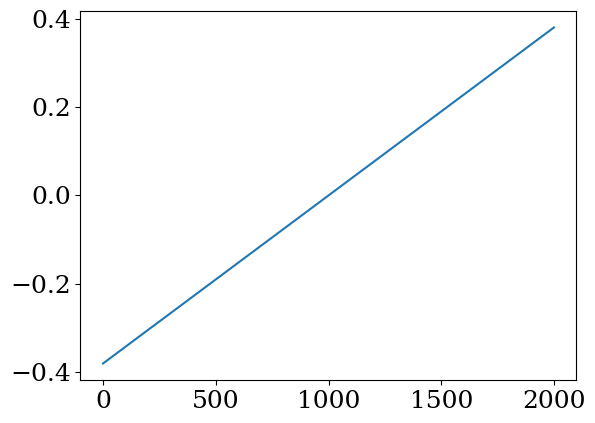

[-0.38125711 -0.38087594 -0.38049478 ...  0.37992955  0.38031072
  0.38069188]


In [6]:
plt.plot(x)
plt.show()
print(x)

In [7]:
drift_slope_linear = fit_km_1_linear(edges, km_1)
c_1 = drift_slope_linear[1]

In [8]:


p3, p2, p1, p0 = fit_km_1_nonlinear_params(0, edges, km_1)

start, end = mid_point - 1000, mid_point + 1000
x = edges[start:end]



q4, q3, q2, q1, q0 = fit_km_2_nonlinear_params(0, edges, km_2)

epsilon_fixed = np.sqrt(2*np.mean(km_2[start:end]))



## Figure 2

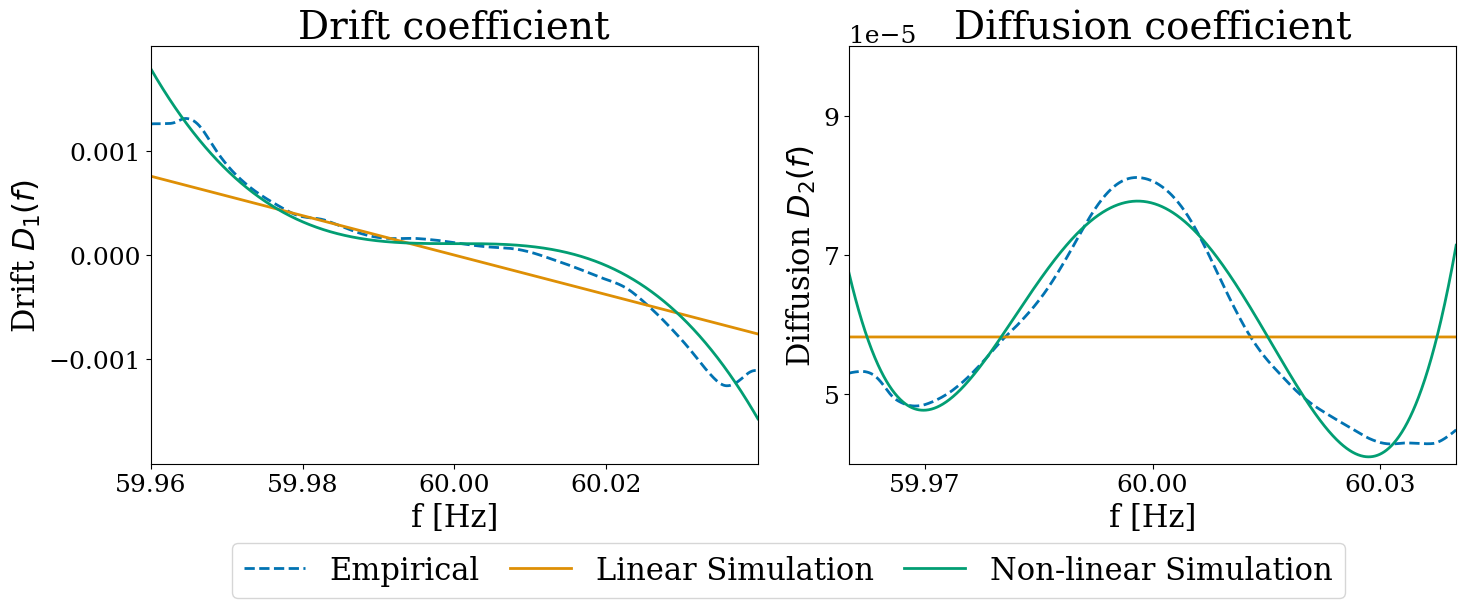

In [9]:
fig,ax = plt.subplots(1,2, figsize=(15,6))

colours = ['k','#D81B60','limegreen']
labels = ['Empirical','Linear Simulation','Non-linear Simulation']
ls = ['--','-','-']

sns.set_palette("tab10")
colour_0,colour_1,colour_2=sns.color_palette("colorblind",3)

legend_elements = [plt.Line2D([0], [0], color=colour_0, lw=2, label=labels[0], ls = ls[0]),
                   plt.Line2D([0], [0], color=colour_1, lw=2, label=labels[1], ls = ls[1]),
                   plt.Line2D([0], [0], color=colour_2, lw=2, label=labels[2], ls = ls[2])
                   ]

ax[0].plot(x/(2*np.pi)+60, km_1[start:end], label = labels[0], color = colour_0, lw=2, ls = ls[0])
ax[0].plot(x/(2*np.pi)+60, -c_1*edges[start:end], label = labels[1], color = colour_1, lw=2, ls = ls[1])
ax[0].plot(x/(2*np.pi)+60, p3*x**3 + 0*p1*x + p0, label = labels[2], color = colour_2, lw=2, ls = ls[2])
ax[0].set_xlim(59.96,60.04)
ax[0].set_ylim(-0.002,0.002)
ax[0].set_title('Drift coefficient')
ax[0].set_xticks(np.arange(59.97,60.04,0.03))
ax[0].set_yticks(np.arange(-0.001,0.002,0.001))

# ax[0].set_xlabel('$\omega$[rad$s^{-1}$]')
ax[0].set_xlabel('f [Hz]', fontsize=22)
ax[0].set_ylabel(r'Drift $D_1(f)$', fontsize=22)
ax[0].set_xticks(np.arange(59.96,60.04,0.02))


ax[1].plot(x/(2*np.pi)+60, (km_2[start:end]), label = labels[0], color = colour_0, lw=2, ls = ls[0])
ax[1].plot(x/(2*np.pi)+60, 0.5*epsilon_fixed**2*np.ones(len(x)), label = labels[1], color = colour_1, lw=2, ls = ls[1])
ax[1].plot(x/(2*np.pi)+60, ((q4*x**4 + q3*x**3 + q2*x**2 + q1*x + q0)), label = labels[2], color = colour_2, lw=2, ls = ls[2])
ax[1].set_xlim(59.96,60.04)
ax[1].set_ylim(0.00004,0.0001)
ax[1].set_xticks(np.arange(59.97,60.04,0.03))
ax[1].set_yticks(np.arange(0.00005,0.0001,0.00002))

#ax[1].set_xlabel('$\omega$[rad$s^{-1}$]')
ax[1].set_xlabel('f [Hz]', fontsize=22)
ax[1].set_ylabel(r'Diffusion $D_2(f)$', fontsize=22)
ax[1].set_title('Diffusion coefficient')

plt.subplots_adjust(wspace = 0.3)
plt.tight_layout()
ax[1].legend(handles = legend_elements,bbox_to_anchor=(-0.1,-0.3,0,0), loc='lower center', columnspacing=1, ncol = 3, borderaxespad=-0.3, fontsize=22)

plt.savefig('./figures/drift_and_diffusion.pdf', bbox_inches='tight', dpi=1200)
plt.show()

In [8]:
new_calculation = True

## Figure 3

In [9]:
if new_calculation:
    # set delta_t and number_of_days
    delta_t = 0.01
    number_of_days = 111
    omega_linear, omega_nonlinear = Euler_Maruyama(p0=p0, p1=p1, p2=p2, p3=p3, q0=q0, q1=q1, q2=q2, q3=q3, q4=q4, epsilon_fixed=epsilon_fixed, delta_t=delta_t, number_of_days=111)
    '''Transform the angular velocity to frequency'''
    step = int(1/delta_t)
    freq_empirical = ang_vel/(2*np.pi)+60
    freq_linear_model = omega_linear[::step]/(2*np.pi)+60
    freq_nonlinear_model = omega_nonlinear[::step]/(2*np.pi)+60

    # Increments:
    freq_increments_empirical = np.diff(freq_empirical)
    freq_increments_linear_model = np.diff(freq_linear_model)
    freq_increments_nonlinear_model = np.diff(freq_nonlinear_model)


NameError: name 'Euler_Maruyama' is not defined

In [ ]:
    ''' Save the data in order to apply the data analysis methods analogously to the empirical data'''
    pd.to_pickle(freq_linear_model, './synthetic_data/freq_linear_model.pkl')
    pd.to_pickle(freq_nonlinear_model, './synthetic_data/freq_nonlinear_model.pkl')
    pd.to_pickle(freq_increments_linear_model, './synthetic_data/freq_increments_linear_model.pkl')
    pd.to_pickle(freq_increments_nonlinear_model, './synthetic_data/freq_increments_nonlinear_model.pkl')

In [6]:
print(freq_linear_model.head(2))

NameError: name 'freq_linear_model' is not defined